# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



# Lab Work


# To Mr. Cameron

In this analysis, I have identified the profiles of passangers that were most likely to survive and least likely to survive for your upcoming reboot of The Titanic. 

The profile of a passanger most likely to survive the sinking would be a young female in either 1st or 2nd class, medium to high fare, travleing with a small family or with children, and embarked from Cherbourg. A real passenger I found fitting this description is Lily May Futrelle, a 35 year old female in 1st class. After survivng the sinking, she later commented on a momnent in the chaos of that night. She encountered a group of men with "smoke-blackened faces" staring at her. These men likely fell into our least likely to survive category. She also stated "they said nothing but their eyes seemed to say, 'at least you have a chance, we have none.'" This could provide a very human moment for the film.

The profile of a passanger least likely to survive the sinking would be an adult male in 3rd class, low fare, traveling alone or with a large family, and embarked from either Southampton or Queenstown. Instead of finding a passanger in the category that fell to statistics, I wanted to find an individual who beat the odds. Fridtjof Arne Madsen was a 24 year old male in 3rd Class. Madsen was travelling with a man named Karl Olsen and Karl's son to New York ,ironically, to attend navigation school and sign on as a second mate on a Norwegian ship. During the night of the sinking, Madsen and Olson secured Olson's son into life boat #13 while they stayed on board. Madsen was picked up in the water by another life boat, however, Karl's body was never found.

(array([0, 1]), [Text(0, 0, 'female'), Text(1, 0, 'male')])

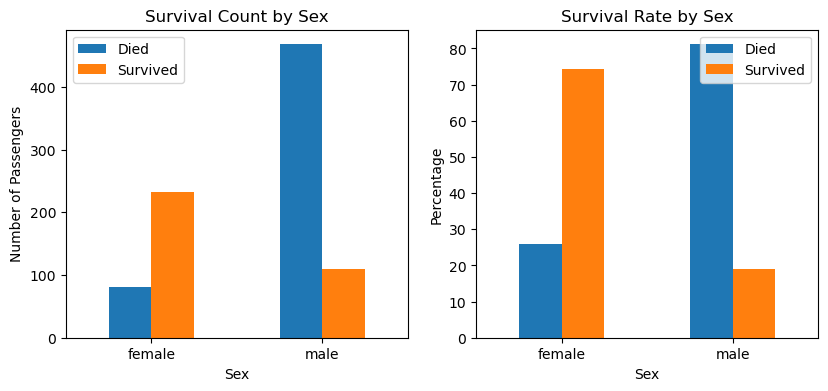

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('titanic_passengers.csv')

# SEX ANALYSIS
sex_survival = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sex_counts = pd.crosstab(df['Sex'], df['Survived'])
sex_counts.plot(kind='bar', ax=plt.gca())
plt.title('Survival Count by Sex')
plt.ylabel('Number of Passengers')
plt.legend(['Died', 'Survived'])
plt.xticks(rotation=0)

plt.subplot(1, 3, 2)
sex_survival.plot(kind='bar', ax=plt.gca())
plt.title('Survival Rate by Sex')
plt.ylabel('Percentage')
plt.legend(['Died', 'Survived'])
plt.xticks(rotation=0)


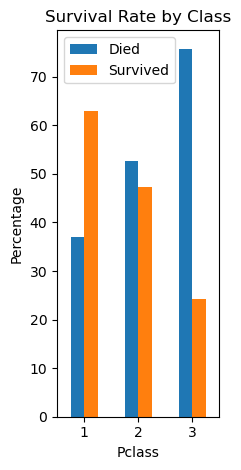

In [ ]:

class_survival = pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100

plt.subplot(1, 3, 3)
class_survival.plot(kind='bar', ax=plt.gca())
plt.title('Survival Rate by Class')
plt.ylabel('Percentage')
plt.legend(['Died', 'Survived'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Child (0-12)'),
  Text(1, 0, 'Teen (13-18)'),
  Text(2, 0, 'Young Adult (19-35)'),
  Text(3, 0, 'Middle-aged (36-60)'),
  Text(4, 0, 'Elderly (60+)')])

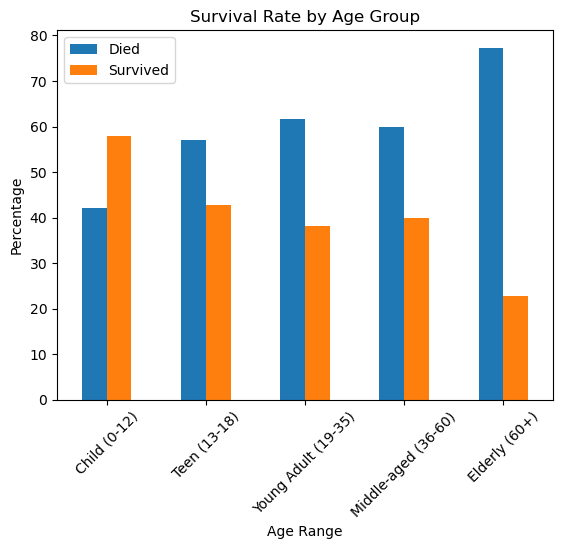

In [70]:
# Create age categories
df['Age_category'] = pd.cut(df['Age'], 
                           bins=[0, 12, 18, 35, 60, 100], 
                           labels=['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)', 
                                  'Middle-aged (36-60)', 'Elderly (60+)'])

age_survival = pd.crosstab(df['Age_category'], df['Survived'], normalize='index') * 100

age_survival.plot(kind='bar')
plt.title('Survival Rate by Age Group')
plt.ylabel('Percentage')
plt.xlabel('Age Range')
plt.legend(['Died', 'Survived'])
plt.xticks(rotation=45)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Low'),
  Text(1, 0, 'Medium-Low'),
  Text(2, 0, 'Medium-High'),
  Text(3, 0, 'High')])

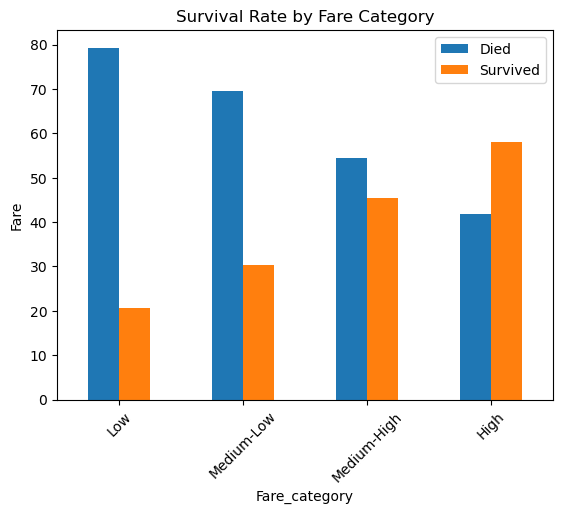

In [61]:
# 4. FARE ANALYSIS
# Create fare categories based on quartiles
fare_quartiles = df['Fare'].quantile([0.25, 0.5, 0.75])

df['Fare_category'] = pd.cut(df['Fare'], 
                            bins=[0, fare_quartiles[0.25], fare_quartiles[0.5], 
                                 fare_quartiles[0.75], df['Fare'].max()], 
                            labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

fare_survival = pd.crosstab(df['Fare_category'], df['Survived'], normalize='index') * 100

fare_survival.plot(kind='bar')
plt.title('Survival Rate by Fare Category')
plt.ylabel('Percentage')
plt.ylabel('Fare')
plt.legend(['Died', 'Survived'])
plt.xticks(rotation=45)


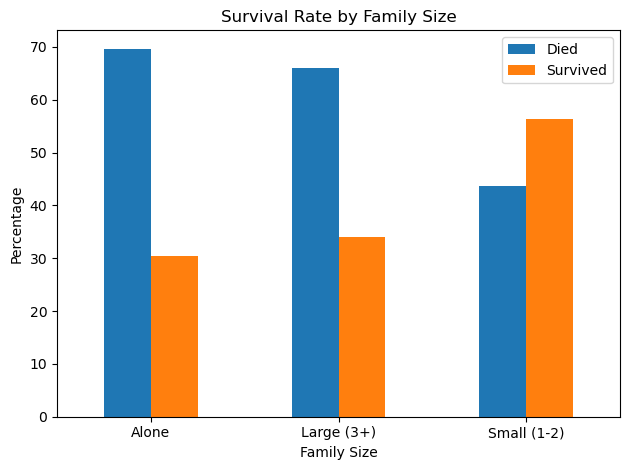

In [72]:

df['FamilySize'] = df['SibSp'] + df['Parch']
df['FamilySize_category'] = df['FamilySize'].apply(
    lambda x: 'Alone' if x == 0 else ('Small (1-2)' if x <= 2 else 'Large (3+)')
)

family_survival = pd.crosstab(df['FamilySize_category'], df['Survived'], normalize='index') * 100


family_survival.plot(kind='bar')
plt.title('Survival Rate by Family Size')
plt.ylabel('Percentage')
plt.xlabel('Family Size')
plt.legend(['Died', 'Survived'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

(array([0, 1, 2]), [Text(0, 0, 'C'), Text(1, 0, 'Q'), Text(2, 0, 'S')])

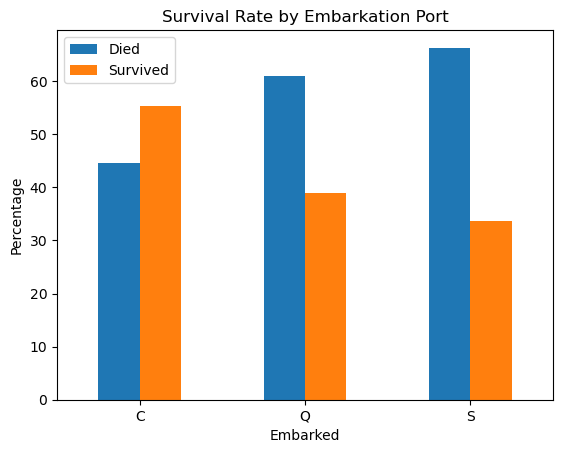

In [49]:
embark_survival = pd.crosstab(df['Embarked'], df['Survived'], normalize='index') * 100

embark_survival.plot(kind='bar')
plt.title('Survival Rate by Embarkation Port')
plt.ylabel('Percentage')
plt.legend(['Died', 'Survived'])
plt.xticks(rotation=0)

In [69]:
# Create filter for most likely survivors
most_likely_filter = (
    (df['Sex'] == 'female') & 
    (df['Pclass'].isin([1, 2])) & 
    (df['Age'] <= 35) & 
    (df['Fare'] >= fare_quartiles[0.5])
)

most_likely_candidates = df[most_likely_filter]
print(f"\nPassengers matching 'most likely' profile: {len(most_likely_candidates)}")
if len(most_likely_candidates) > 0:
    survival_rate = most_likely_candidates['Survived'].mean()
    print(f"Survival rate for this profile: {survival_rate:.2%}")
    
    # Find actual survivors matching this profile
    survivors = most_likely_candidates[most_likely_candidates['Survived'] == 1]
    if len(survivors) > 0:
        print("\nReal passengers who fit this profile and survived:")
        for i, (idx, passenger) in enumerate(survivors.head(3).iterrows()):
            print(f"{i+1}. {passenger['Name']} - Age: {passenger['Age']}, Class: {passenger['Pclass']}, Fare: ${passenger['Fare']:.2f}")

# Create filter for least likely survivors
least_likely_filter = (
    (df['Sex'] == 'male') & 
    (df['Pclass'] == 3) & 
    (df['Age'] > 12) & 
    (df['Fare'] <= fare_quartiles[0.25])
)

least_likely_candidates = df[least_likely_filter]
print(f"\nPassengers matching 'least likely' profile: {len(least_likely_candidates)}")
if len(least_likely_candidates) > 0:
    survival_rate = least_likely_candidates['Survived'].mean()
    print(f"Survival rate for this profile: {survival_rate:.2%}")
    
    # Find those who didn't survive matching this profile
    non_survivors = least_likely_candidates[least_likely_candidates['Survived'] == 0]
    if len(non_survivors) > 0:
        print("\nReal passengers who fit this profile and did not survive:")
        for i, (idx, passenger) in enumerate(non_survivors.head(3).iterrows()):
            print(f"{i+1}. {passenger['Name']} - Age: {passenger['Age']}, Class: {passenger['Pclass']}, Fare: ${passenger['Fare']:.2f}")

    # Find those who didn't survive matching this profile
    lucky_survivors = least_likely_candidates[least_likely_candidates['Survived'] == 1]
    if len(lucky_survivors) > 0:
        print("\nReal passengers who fit this profile and DID survive:")
        for i, (idx, passenger) in enumerate(lucky_survivors.head(3).iterrows()):
            print(f"{i+1}. {passenger['Name']} - Age: {passenger['Age']}, Class: {passenger['Pclass']}, Fare: ${passenger['Fare']:.2f}")



Passengers matching 'most likely' profile: 82
Survival rate for this profile: 95.12%

Real passengers who fit this profile and survived:
1. Futrelle, Mrs. Jacques Heath (Lily May Peel) - Age: 35.0, Class: 1, Fare: $53.10
2. Nasser, Mrs. Nicholas (Adele Achem) - Age: 14.0, Class: 2, Fare: $30.07
3. Laroche, Miss. Simonne Marie Anne Andree - Age: 3.0, Class: 2, Fare: $41.58

Passengers matching 'least likely' profile: 116
Survival rate for this profile: 9.48%

Real passengers who fit this profile and did not survive:
1. Braund, Mr. Owen Harris - Age: 22.0, Class: 3, Fare: $7.25
2. Nosworthy, Mr. Richard Cater - Age: 21.0, Class: 3, Fare: $7.80
3. Novel, Mr. Mansouer - Age: 28.5, Class: 3, Fare: $7.23

Real passengers who fit this profile and DID survive:
1. Madsen, Mr. Fridtjof Arne - Age: 24.0, Class: 3, Fare: $7.14
2. Andersson, Mr. August Edvard ("Wennerstrom") - Age: 27.0, Class: 3, Fare: $7.80
3. Persson, Mr. Ernst Ulrik - Age: 25.0, Class: 3, Fare: $7.78
